In [1]:
import sys
sys.path.append("../Classes")
from Solution import Solution
from Persistence import PersistMultipleSolutions, PersistSingleSolution
from utils import boxplot_fx, boxplot_convergence, get_fx_samples
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

ils = PersistMultipleSolutions().load(filename="ils_800",
                                      filepath="./ils/results/")
vns = PersistMultipleSolutions().load(filename="vns_800",
                                        filepath="./vns/results/")
ga = PersistMultipleSolutions().load(filename="ga_800",
                                      filepath="./ga/results/")
optimum = PersistSingleSolution().load(filename="globopt_800",
                                      filepath="./global_optimum/solutions/")
vns_45 = PersistMultipleSolutions().load(filename="vns_800_45",
                                        filepath="./vns/results/")

ils = ils[2]
vns = vns[3]
ga = ga[2]
vns_45 = vns_45[0]
solutions = [ils, vns, ga, vns_45]
names = ["ILS", "VNS", "GA", "VNS_45"]

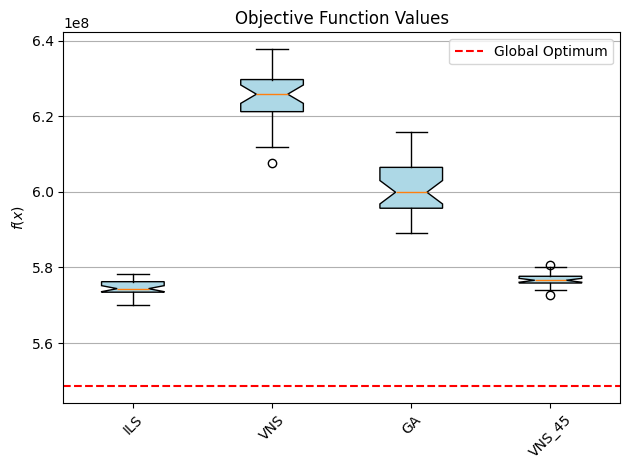

In [2]:
boxplot_fx(solutions, names, global_optimum=optimum)

In [5]:
from scipy.stats import shapiro, ttest_ind
fx = get_fx_samples(solutions)
print("Shapiro-Wilk Test p-values:")
for i in range(fx.shape[0]):
    stat, p = shapiro(fx[i])
    print(f"Algorithm {i+1}: {p:.4f}")

print("\nT-test p-value between Algorithm 0 and 3:")
stat, p = ttest_ind(fx[0], fx[3], equal_var=False, alternative='less')
print(f"{p:.4f}")

Shapiro-Wilk Test p-values:
Algorithm 1: 0.8824
Algorithm 2: 0.3561
Algorithm 3: 0.4394
Algorithm 4: 0.7861

T-test p-value between Algorithm 0 and 3:
0.0000


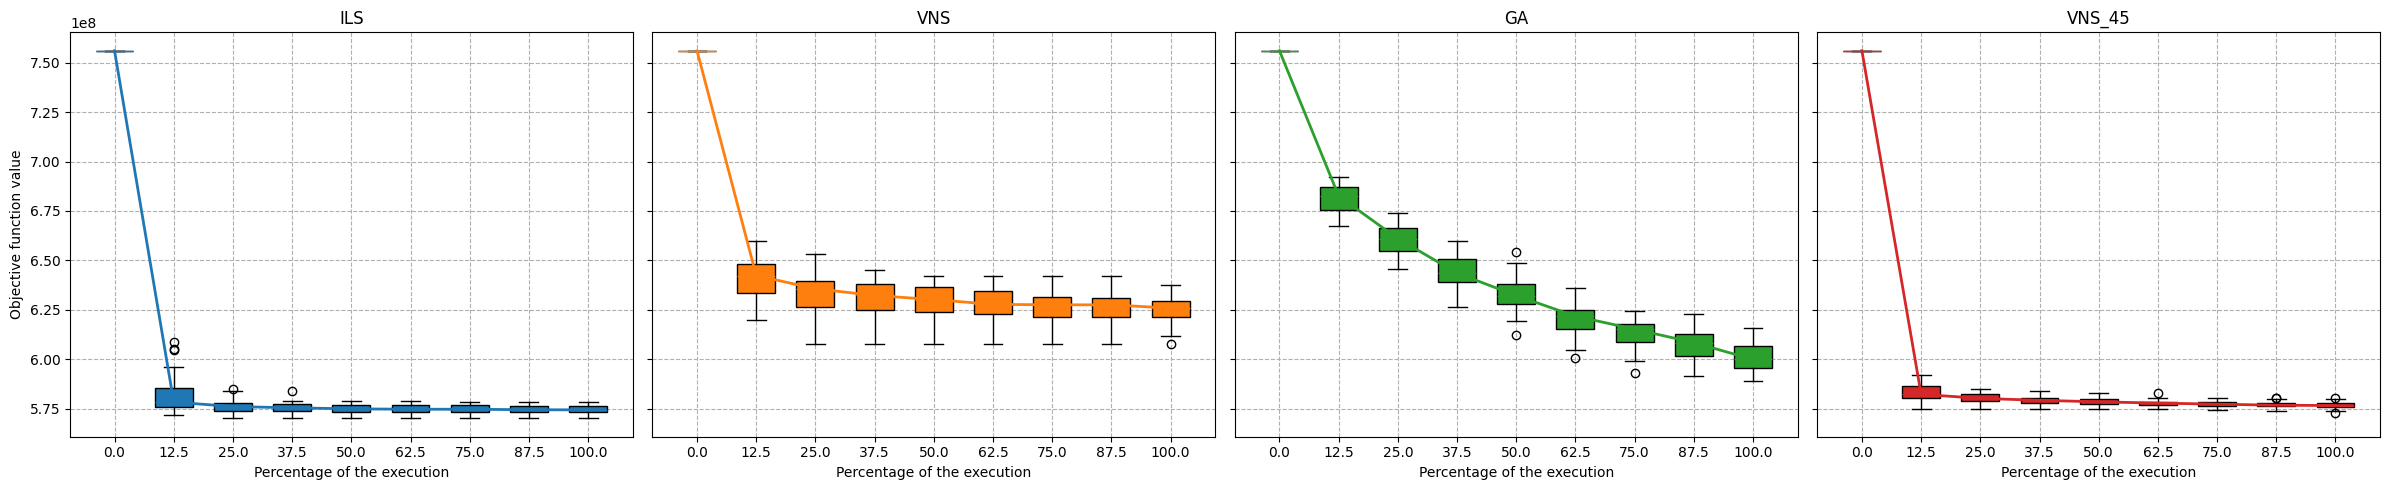

In [4]:
boxplot_convergence(solutions, names)